In [1]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata
import re

Notas

In [2]:
#Notas varados
varados = pd.read_excel(
    'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/notas_fms.xlsx',
    sheet_name='Varados'
)

#Notas ruteros
ruteros = pd.read_excel(
    'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/notas_fms.xlsx',
    sheet_name='Ruteros'
)

ruteros.head()

,Fecha,Concesión,Concesionario de Operación,Tipo de Servicio,Id de línea,Nombre Línea,N° Vehículo,Código Conductor,Subsubtipo Nota,Observaciones,Creado Por,Modificado Por,Mes
0,2026-01-02 12:20:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504454,507308,RUTERO - VIA,Varado / rutero electrónico / 02-01-2026 / 12:...,JHON JAIRO ESPINOSA SANTA,JHON JAIRO ESPINOSA SANTA,enero
1,2026-01-03 11:05:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504469,510149,RUTERO - VIA,varado / rutero electrónico fuera de servicio ...,JHON JAIRO ESPINOSA SANTA,JHON JAIRO ESPINOSA SANTA,enero
2,2026-01-26 16:46:00,ENGATIVA ZN,GMOVIL ENGATIVA,URBANO,10273,142,504470,502975,RUTERO - VIA,FALLA TÉCNICA / Rutero electrónico fuera de se...,SONIA CORREA CONSTANZA RODRIGUEZ,SONIA CORREA CONSTANZA RODRIGUEZ,enero
3,2026-02-09 11:19:00,ENGATIVA ZN,GMOVIL ENGATIVA,URBANO,10273,142,504440,510361,RUTERO - VIA,Varado / Rutero electrónico fuera deservicio ...,WILSON TORRES ABEL FAJARDO,WILSON TORRES ABEL FAJARDO,febrero
4,2026-02-20 18:34:00,ENGATIVA ZN,GMOVIL ENGATIVA,URBANO,10273,142,502072,509013,RUTERO - VIA,Varado / Rutero electrónico fuera deservicio ...,MARTHA IBETH MARTIN MARTIN,MARTHA IBETH MARTIN MARTIN,febrero


In [3]:
col = varados['Observaciones'].astype(str)

# 🔹 1. HORA (todo lo que tenga :)
varados['hora_novedad'] = col.str.extract(r'(\d{1,2}:\d{2})')[0]

# 🔹 2. RUTA
varados['ruta_novedad'] = col.str.extract(
    r'(DL\d+|BD\d+|KL\d+|KB\d+|DH\d+|DA\d+|DD\d+|GC\d+|SE\d+|C\d+|RT\s*\d+|'
    r'\b(?:577|614|740|576|466|402|P500|E25|DB237|539|128)\b|'
    r'SERVICIO\s*[^/]+|RUTA\s*[A-Z0-9]+)',
    flags=re.IGNORECASE
)[0]

# limpiar "Ruta"
varados['ruta_novedad'] = (
    varados['ruta_novedad']
    .str.replace(r'RUTA\s*', '', regex=True)
    .str.strip()
)

# 🔹 3. TABLA
varados['tabla_novedad'] = (
    col.str.extract(r'((?:TABLA|TB|TBL)\s*\d+)', flags=re.IGNORECASE)[0]
    .fillna('0')
)

# 🔹 4. DIRECCIÓN
varados['direccion_novedad'] = col.str.extract(
    r'([^/]*(AV\.?|AVENIDA|CALLE|CRA\.?|CARRERA|BOYACÁ|BOYACA|CALI|Portal|Transversal|CARACAS)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

#Bus

varados['bus_novedad'] = (
    col.str.upper()
    
    # 🔹 limpiar ruido
    .str.replace(r'MÓVIL|MOVIL|ZONAL|ZZ', '', regex=True)
    
    # 🔹 extraer bus completo (con números obligatorios)
    .str.extract(r'(Z?\s*(?:50|52)\s*-?\s*\d{3,5})', flags=re.IGNORECASE)[0]
    
    # 🔹 limpiar espacios
    .str.replace(r'\s+', '', regex=True)
    
    # 🔹 estandarizar formato
    .str.replace(r'^(50|52)', r'Z\1', regex=True)
    .str.replace(r'Z(50|52)(\d+)', r'Z\1-\2', regex=True)
    
    # 🔹 llenar vacíos
    .fillna('0')
)

# 🔹 5. NOVEDAD (texto operativo)
varados['novedad_val'] = col.str.extract(
    r'([^/]*(SE EVIDENCIA|SE EVIDENCIÓ|NO ACTIVA|OPERADOR OMITE|El OPERADOR|TRANSITA|EVIDENCIADO|INVADE|TRANSITANDO|OMITIR|LUZ|DIRECCIONAL|CARRIL|SE PRESENTA NOVEDAD|RETORNO|'
    r'NOVEDAD|ELEMENTO|MALETA|LUCES?|MARCHA|IRREGULAR|USUARIO|PARE|SEMAFORO|ACTIVA|DESVIO|NO AUTORIZADO|AUDIFONOS|AURICULAR|PUERTA|DESVÍO|DESVÍA|SIN AUTORIZACION|PARADA|ALTERAR|MANIPULACION|DISPOSITIVO|'
    r'PRENDAS|VELOCIDAD|EXCESO)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

varados.head(2)

,Fecha,Concesión,Concesionario de Operación,Tipo de Servicio,Id de línea,Nombre Línea,N° Vehículo,Código Conductor,Nombre Conductor,ID Nota,...,Observaciones,Creado Por,Modificado Por,Mes,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
0,2026-01-01 07:50:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10184.0,740,504373.0,509930.0,HAMER ALEXANDER ROMERO GARNICA,637703,...,Varado / Puertas Fuera de servicio / 01-01-202...,Raul Fabian Romero Mican,Raul Fabian Romero Mican,enero,07:48,servicio,Tb 8,diagonal 50 sur con carrera 5bis este,Z50-4373,Puertas Fuera de servicio
1,2026-01-01 06:42:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10261.0,466,504190.0,508637.0,DEISON JAVIER HERNANDEZ LIZARAZO,637656,...,FALLA TÉCNICA / Luces Estacionarias quedan fij...,JINNETH GUZMAN ALEXANDRA HERNANDEZ,JINNETH GUZMAN ALEXANDRA HERNANDEZ,enero,06:42,servicio),Tb 5,calle 63 con carrera 98,Z50-4190,Luces Estacionarias quedan fijas (Botón de man...


In [4]:
varados['Fecha'] = pd.to_datetime(varados['Fecha'], errors='coerce')

varados['fecha_nota'] = varados['Fecha'].dt.strftime('%Y-%m-%d')
varados['hora_nota'] = varados['Fecha'].dt.strftime('%H:%M:%S')

varados.head(2)


,Fecha,Concesión,Concesionario de Operación,Tipo de Servicio,Id de línea,Nombre Línea,N° Vehículo,Código Conductor,Nombre Conductor,ID Nota,...,Modificado Por,Mes,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,fecha_nota,hora_nota
0,2026-01-01 07:50:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10184.0,740,504373.0,509930.0,HAMER ALEXANDER ROMERO GARNICA,637703,...,Raul Fabian Romero Mican,enero,07:48,servicio,Tb 8,diagonal 50 sur con carrera 5bis este,Z50-4373,Puertas Fuera de servicio,2026-01-01,07:50:00
1,2026-01-01 06:42:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10261.0,466,504190.0,508637.0,DEISON JAVIER HERNANDEZ LIZARAZO,637656,...,JINNETH GUZMAN ALEXANDRA HERNANDEZ,enero,06:42,servicio),Tb 5,calle 63 con carrera 98,Z50-4190,Luces Estacionarias quedan fijas (Botón de man...,2026-01-01,06:42:00


In [5]:
# Función para corregir tiempos con "24:00:00"
def fix_time(time_str):
    try:
        time_str = str(time_str).strip()
        h, m, s = map(int, time_str.split(':'))

        # Convertir TODO a segundos
        total_segundos = h * 3600 + m * 60 + s

        # Reducir al rango de 24h
        total_segundos = total_segundos % (24 * 3600)

        # Volver a formato hh:mm:ss
        h_new = total_segundos // 3600
        m_new = (total_segundos % 3600) // 60
        s_new = total_segundos % 60

        return f"{h_new:02}:{m_new:02}:{s_new:02}"

    except:
        return None

varados['hora_nota'] = varados['hora_nota'].astype(str)

varados['hora_nota'] = varados['hora_nota'].apply(fix_time)

varados['hora_nota'] = pd.to_datetime(
    varados['hora_nota'],
    format='%H:%M:%S',
    errors='coerce'
)

varados['Hora_Segundos'] = (
    varados['hora_nota'].dt.hour * 3600 +
    varados['hora_nota'].dt.minute * 60 +
    varados['hora_nota'].dt.second
)

varados.head(2)

,Fecha,Concesión,Concesionario de Operación,Tipo de Servicio,Id de línea,Nombre Línea,N° Vehículo,Código Conductor,Nombre Conductor,ID Nota,...,Mes,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,fecha_nota,hora_nota,Hora_Segundos
0,2026-01-01 07:50:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10184.0,740,504373.0,509930.0,HAMER ALEXANDER ROMERO GARNICA,637703,...,enero,07:48,servicio,Tb 8,diagonal 50 sur con carrera 5bis este,Z50-4373,Puertas Fuera de servicio,2026-01-01,1900-01-01 07:50:00,28200
1,2026-01-01 06:42:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10261.0,466,504190.0,508637.0,DEISON JAVIER HERNANDEZ LIZARAZO,637656,...,enero,06:42,servicio),Tb 5,calle 63 con carrera 98,Z50-4190,Luces Estacionarias quedan fijas (Botón de man...,2026-01-01,1900-01-01 06:42:00,24120


In [6]:
#ruteros

col = ruteros['Observaciones'].astype(str)

# 🔹 1. HORA (todo lo que tenga :)
ruteros['hora_novedad'] = col.str.extract(r'(\d{1,2}:\d{2})')[0]

# 🔹 2. RUTA
ruteros['ruta_novedad'] = col.str.extract(
    r'(DL\d+|BD\d+|KL\d+|KB\d+|DH\d+|DA\d+|DD\d+|GC\d+|SE\d+|C\d+|RT\s*\d+|'
    r'\b(?:577|614|740|576|466|402|P500|E25|DB237|539|128)\b|'
    r'SERVICIO\s*[^/]+|RUTA\s*[A-Z0-9]+)',
    flags=re.IGNORECASE
)[0]

# limpiar "Ruta"
ruteros['ruta_novedad'] = (
    ruteros['ruta_novedad']
    .str.replace(r'RUTA\s*', '', regex=True)
    .str.strip()
)

# 🔹 3. TABLA
ruteros['tabla_novedad'] = (
    col.str.extract(r'((?:TABLA|TB|TBL)\s*\d+)', flags=re.IGNORECASE)[0]
    .fillna('0')
)

# 🔹 4. DIRECCIÓN
ruteros['direccion_novedad'] = col.str.extract(
    r'([^/]*(AV\.?|AVENIDA|CALLE|CRA\.?|CARRERA|BOYACÁ|BOYACA|CALI|Portal|Transversal|CARACAS)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

#Bus

ruteros['bus_novedad'] = (
    col.str.upper()
    
    # 🔹 limpiar ruido
    .str.replace(r'MÓVIL|MOVIL|ZONAL|ZZ', '', regex=True)
    
    # 🔹 extraer bus completo (con números obligatorios)
    .str.extract(r'(Z?\s*(?:50|52)\s*-?\s*\d{3,5})', flags=re.IGNORECASE)[0]
    
    # 🔹 limpiar espacios
    .str.replace(r'\s+', '', regex=True)
    
    # 🔹 estandarizar formato
    .str.replace(r'^(50|52)', r'Z\1', regex=True)
    .str.replace(r'Z(50|52)(\d+)', r'Z\1-\2', regex=True)
    
    # 🔹 llenar vacíos
    .fillna('0')
)

# 🔹 5. NOVEDAD (texto operativo)
ruteros['novedad_val'] = col.str.extract(
    r'([^/]*(SE EVIDENCIA|SE EVIDENCIÓ|NO ACTIVA|OPERADOR OMITE|El OPERADOR|TRANSITA|EVIDENCIADO|INVADE|TRANSITANDO|OMITIR|LUZ|DIRECCIONAL|CARRIL|SE PRESENTA NOVEDAD|RETORNO|'
    r'NOVEDAD|ELEMENTO|MALETA|LUCES?|MARCHA|IRREGULAR|USUARIO|PARE|SEMAFORO|ACTIVA|DESVIO|NO AUTORIZADO|AUDIFONOS|AURICULAR|PUERTA|DESVÍO|DESVÍA|SIN AUTORIZACION|PARADA|ALTERAR|MANIPULACION|DISPOSITIVO|'
    r'PRENDAS|VELOCIDAD|EXCESO)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

ruteros.head(2)


,Fecha,Concesión,Concesionario de Operación,Tipo de Servicio,Id de línea,Nombre Línea,N° Vehículo,Código Conductor,Subsubtipo Nota,Observaciones,Creado Por,Modificado Por,Mes,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
0,2026-01-02 12:20:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504454,507308,RUTERO - VIA,Varado / rutero electrónico / 02-01-2026 / 12:...,JHON JAIRO ESPINOSA SANTA,JHON JAIRO ESPINOSA SANTA,enero,12:20,Ruta 142,Tb 7,calle 40b con carrera 13 parada 235A00,Z50-4454,calle 40b con carrera 13 parada 235A00
1,2026-01-03 11:05:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504469,510149,RUTERO - VIA,varado / rutero electrónico fuera de servicio ...,JHON JAIRO ESPINOSA SANTA,JHON JAIRO ESPINOSA SANTA,enero,10:46,servicio,Tb 8,carrera 121 con calle 63 g parada 038a05,Z50-4469,carrera 121 con calle 63 g parada 038a05


In [7]:
ruteros['Fecha'] = pd.to_datetime(ruteros['Fecha'], errors='coerce')

ruteros['fecha_nota'] = ruteros['Fecha'].dt.strftime('%Y-%m-%d')
ruteros['hora_nota'] = ruteros['Fecha'].dt.strftime('%H:%M:%S')

ruteros.head(2)

,Fecha,Concesión,Concesionario de Operación,Tipo de Servicio,Id de línea,Nombre Línea,N° Vehículo,Código Conductor,Subsubtipo Nota,Observaciones,...,Modificado Por,Mes,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,fecha_nota,hora_nota
0,2026-01-02 12:20:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504454,507308,RUTERO - VIA,Varado / rutero electrónico / 02-01-2026 / 12:...,...,JHON JAIRO ESPINOSA SANTA,enero,12:20,Ruta 142,Tb 7,calle 40b con carrera 13 parada 235A00,Z50-4454,calle 40b con carrera 13 parada 235A00,2026-01-02,12:20:00
1,2026-01-03 11:05:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504469,510149,RUTERO - VIA,varado / rutero electrónico fuera de servicio ...,...,JHON JAIRO ESPINOSA SANTA,enero,10:46,servicio,Tb 8,carrera 121 con calle 63 g parada 038a05,Z50-4469,carrera 121 con calle 63 g parada 038a05,2026-01-03,11:05:00


In [8]:
# Función para corregir tiempos con "24:00:00"
def fix_time(time_str):
    try:
        time_str = str(time_str).strip()
        h, m, s = map(int, time_str.split(':'))

        # Convertir TODO a segundos
        total_segundos = h * 3600 + m * 60 + s

        # Reducir al rango de 24h
        total_segundos = total_segundos % (24 * 3600)

        # Volver a formato hh:mm:ss
        h_new = total_segundos // 3600
        m_new = (total_segundos % 3600) // 60
        s_new = total_segundos % 60

        return f"{h_new:02}:{m_new:02}:{s_new:02}"

    except:
        return None

ruteros['hora_nota'] = ruteros['hora_nota'].astype(str)

ruteros['hora_nota'] = ruteros['hora_nota'].apply(fix_time)

ruteros['hora_nota'] = pd.to_datetime(
    ruteros['hora_nota'],
    format='%H:%M:%S',
    errors='coerce'
)

ruteros['Hora_Segundos'] = (
    ruteros['hora_nota'].dt.hour * 3600 +
    ruteros['hora_nota'].dt.minute * 60 +
    ruteros['hora_nota'].dt.second
)

ruteros.head(2)

,Fecha,Concesión,Concesionario de Operación,Tipo de Servicio,Id de línea,Nombre Línea,N° Vehículo,Código Conductor,Subsubtipo Nota,Observaciones,...,Mes,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,fecha_nota,hora_nota,Hora_Segundos
0,2026-01-02 12:20:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504454,507308,RUTERO - VIA,Varado / rutero electrónico / 02-01-2026 / 12:...,...,enero,12:20,Ruta 142,Tb 7,calle 40b con carrera 13 parada 235A00,Z50-4454,calle 40b con carrera 13 parada 235A00,2026-01-02,1900-01-01 12:20:00,44400
1,2026-01-03 11:05:00,"ENGATIVA ZN, ENGATIVA AL, ENGATIVA T3",GMOVIL ENGATIVA,URBANO,10273,142,504469,510149,RUTERO - VIA,varado / rutero electrónico fuera de servicio ...,...,enero,10:46,servicio,Tb 8,carrera 121 con calle 63 g parada 038a05,Z50-4469,carrera 121 con calle 63 g parada 038a05,2026-01-03,1900-01-01 11:05:00,39900


Ico_procesado

In [9]:
ico_procesado = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/Control Transmitools ICO.csv', encoding='latin', sep=';')

ico_procesado.head(3)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÓN DE NOVEDAD,Evidencias,Área,Patio,Año,Mes
0,71661761812,1697825,39953,Int. Operaciones,1/01/2026,5/01/2026,I8024,No aplicar manejo preventivo.,10,509461,Z50-4174,806,01/01/2026/ 11:42/ Ruta806/Tabla1/Av Boyacá co...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero
1,71661761814,1697842,39949,Int. Operaciones,1/01/2026,5/01/2026,I6025,Incorrecta aproximación a las plataformas y/o ...,10,509656,Z50-4356,740,01/01/2026/ 09:25/ Ruta740/Tabla1/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero
2,71661761816,1697828,39963,Int. Operaciones,1/01/2026,5/01/2026,I6019,No seguir o desconocer las instrucciones dadas...,15,502205,Z50-4144,DA218,01/01/2026/ 12:09/ RutaDA218/Tabla5/Calle 72 c...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero


In [10]:
valores = ['I5023-3', 'I8007', 'I8007-1', 'I6017-2']

ico_procesado = ico_procesado[ico_procesado['Cód. Infracción TMSA'].isin(valores)]

ico_procesado.head(2)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÓN DE NOVEDAD,Evidencias,Área,Patio,Año,Mes
9,71661761827,1698720,40063,Int. Operaciones,3/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,509878,Z50-2021,KL307,03/01/2026/ 08:40/ RutaKL307/Tabla10/Carrera 1...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,enero
11,71661761832,1698700,40057,Int. Operaciones,3/01/2026,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,Z50-4178,806,03-01-2026/Hora 07:48/Ruta 806/Tabla 3 /Direcc...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero


In [11]:
#ruteros electronicos

patron_rutero = r'\b(rutero|ruteros|electronico|electronicos|electrónico|electrónicos|sentido|ruta|correcto)\b'

patron_excluir = r'\b(carril|izquierdo|derecho|acompañante|riesgo|descenso|puertas|desvió|desviar|desvía)\b'

ico_procesado['item_rutero'] = np.where(
    (
        ico_procesado['DESCRIPCIÓN DE NOVEDAD'].str.contains(
            patron_rutero, case=False, na=False, regex=True
        )
    ) &
    (
        ~ico_procesado['DESCRIPCIÓN DE NOVEDAD'].str.contains(
            patron_excluir, case=False, na=False, regex=True
        )
    ),
    'RUTERO / SEÑALIZACIÓN',
    np.nan
)

ico_procesado.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_22420\1738090258.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ico_procesado['DESCRIPCIÓN DE NOVEDAD'].str.contains(
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_22420\1738090258.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~ico_procesado['DESCRIPCIÓN DE NOVEDAD'].str.contains(


,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÓN DE NOVEDAD,Evidencias,Área,Patio,Año,Mes,item_rutero
9,71661761827,1698720,40063,Int. Operaciones,3/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,509878,Z50-2021,KL307,03/01/2026/ 08:40/ RutaKL307/Tabla10/Carrera 1...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,enero,nan
11,71661761832,1698700,40057,Int. Operaciones,3/01/2026,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,Z50-4178,806,03-01-2026/Hora 07:48/Ruta 806/Tabla 3 /Direcc...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero,RUTERO / SEÑALIZACIÓN
16,71661761830,1698996,40113,Int. Operaciones,4/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,506464,Z50-4380,740,04/01/2026/ 10:23/ Ruta740/Tabla6/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero,nan


In [12]:
ico_procesado['flag_rutero'] = 0

ico_procesado.loc[
    (ico_procesado['item_rutero'] == 'RUTERO / SEÑALIZACIÓN') &
    (ico_procesado['Cód. Infracción TMSA'] == 'I5023-3'),
    'flag_rutero'
] = 1

ico_procesado.head(3)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÓN DE NOVEDAD,Evidencias,Área,Patio,Año,Mes,item_rutero,flag_rutero
9,71661761827,1698720,40063,Int. Operaciones,3/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,509878,Z50-2021,KL307,03/01/2026/ 08:40/ RutaKL307/Tabla10/Carrera 1...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,enero,nan,0
11,71661761832,1698700,40057,Int. Operaciones,3/01/2026,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,Z50-4178,806,03-01-2026/Hora 07:48/Ruta 806/Tabla 3 /Direcc...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero,RUTERO / SEÑALIZACIÓN,0
16,71661761830,1698996,40113,Int. Operaciones,4/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,506464,Z50-4380,740,04/01/2026/ 10:23/ Ruta740/Tabla6/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero,nan,0


In [13]:
patron = r'\b(prenda|prendas|uniforme|gorra|gorras|camiseta|camisetas|camisa|camisas|chaqueta|chaquetas|manga|mangas)\b'

ico_procesado['item_novedad'] = np.where(
    ico_procesado['DESCRIPCIÓN DE NOVEDAD'].str.contains(patron, case=False, na=False, regex=True),
    'INDUMENTARIA',
    np.nan
)

ico_procesado.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_22420\820905920.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ico_procesado['DESCRIPCIÓN DE NOVEDAD'].str.contains(patron, case=False, na=False, regex=True),


,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,Ruta,DESCRIPCIÓN DE NOVEDAD,Evidencias,Área,Patio,Año,Mes,item_rutero,flag_rutero,item_novedad
9,71661761827,1698720,40063,Int. Operaciones,3/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,509878,...,KL307,03/01/2026/ 08:40/ RutaKL307/Tabla10/Carrera 1...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,enero,nan,0,nan
11,71661761832,1698700,40057,Int. Operaciones,3/01/2026,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,806,03-01-2026/Hora 07:48/Ruta 806/Tabla 3 /Direcc...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero,RUTERO / SEÑALIZACIÓN,0,nan
16,71661761830,1698996,40113,Int. Operaciones,4/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,506464,...,740,04/01/2026/ 10:23/ Ruta740/Tabla6/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero,nan,0,nan


In [14]:
ico_procesado['flag_indumentaria'] = 0

ico_procesado.loc[
    (ico_procesado['item_novedad'] == 'INDUMENTARIA') &
    (ico_procesado['Cód. Infracción TMSA'] == 'I5023-3'),
    'flag_indumentaria'
] = 1

ico_procesado.head(3)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,DESCRIPCIÓN DE NOVEDAD,Evidencias,Área,Patio,Año,Mes,item_rutero,flag_rutero,item_novedad,flag_indumentaria
9,71661761827,1698720,40063,Int. Operaciones,3/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,509878,...,03/01/2026/ 08:40/ RutaKL307/Tabla10/Carrera 1...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2026,enero,nan,0,nan,0
11,71661761832,1698700,40057,Int. Operaciones,3/01/2026,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,03-01-2026/Hora 07:48/Ruta 806/Tabla 3 /Direcc...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero,RUTERO / SEÑALIZACIÓN,0,nan,0
16,71661761830,1698996,40113,Int. Operaciones,4/01/2026,6/01/2026,I5023-3,No cumplir con los lineamientos establecidos e...,10,506464,...,04/01/2026/ 10:23/ Ruta740/Tabla6/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero,nan,0,nan,0


In [15]:
ico_procesado = ico_procesado[
    ~(
        (ico_procesado['Cód. Infracción TMSA'] == 'I5023-3') &
        (ico_procesado['flag_indumentaria'] == 0) &
        (ico_procesado['flag_rutero'] == 0)
    )
]

ico_procesado.head(3)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,DESCRIPCIÓN DE NOVEDAD,Evidencias,Área,Patio,Año,Mes,item_rutero,flag_rutero,item_novedad,flag_indumentaria
11,71661761832,1698700,40057,Int. Operaciones,3/01/2026,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,03-01-2026/Hora 07:48/Ruta 806/Tabla 3 /Direcc...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2026,enero,RUTERO / SEÑALIZACIÓN,0,nan,0
21,71661761839,1699810,40355,Int. Operaciones,5/01/2026,7/01/2025,I8007,Autorregular los tiempos de un servicio sin au...,30,509546,...,05-01-2026/Hora 18:52/Ruta 142/Tabla 6 /Direcc...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero,RUTERO / SEÑALIZACIÓN,0,nan,0
32,71661761849,1700666,40601,Int. Operaciones,6/01/2026,8/01/2026,I8007,Autorregular los tiempos de un servicio sin au...,30,509444,...,06-01-2026 /Hora 15:47/Ruta DB237/Tabla 29 /Di...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2026,enero,RUTERO / SEÑALIZACIÓN,0,nan,0


In [16]:
# ico_procesado = ico_procesado[
#     ~(
#         (ico_procesado['Cód. Infracción TMSA'] == 'I5023-3') &
#         (ico_procesado['flag_indumentaria'] == 0)
#     )
# ]

# ico_procesado.head(3)

Paraderos

In [17]:
#importar paradas

paradas = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Paraderos_Zonales_del_SITP.csv')

paradas.head(3)

,X,Y,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape
0,1.001502e+06,1.010205e+06,1,001A00,00,C.C. Iserra 100,AC 100,AC 100 - KR 54,Barrios Unidos,-74.063971,4.688481,001,M,AC 100 - KR 54 (001A00),AC 100 - KR 54,Avenida Calle 100 Carrera 54,C,{1C0DBC4E-15BC-4BBE-BC16-5628077DBE2E},NaN
1,1.003505e+06,1.009719e+06,2,001A01,01,Br. Rincón del Chicó,AC 100,AC 100 - KR 13,Usaquén,-74.045914,4.684091,001,M,AC 100 - KR 13 (001A01),AC 100 - KR 13,Avenida Calle 100 Carrera 13,B,{60A22A44-AD56-4DF4-A3E6-6830B9FB0792},NaN
2,1.001238e+06,1.018098e+06,3,001A02,02,Gimnasio Iragua,AV. Boyacá,AV. Boyacá - AC 170,Suba,-74.066350,4.759867,001,S,AV. Boyacá - AC 170 (001A02),AV. Boyacá - AC 170,Avenida Boyacá Avenida Calle 170,C,{97155274-E4D5-45A4-891F-2DCA19FF10D9},NaN


Estado operadores

In [18]:
estado_op = pd.read_excel('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/Estado_de_Conductores.xlsx')

estado_op.head()

,Concesión,Concesionario de Operación,Estado de Vinculación,Tipo de Vehículo,Tipo de Documento,Número de Documento,Código de Conductor,Nombre,Fecha de Ingreso,Fecha de Vinculación,Fecha de Retiro,Género,Fecha de Nacimiento,Edad
0,ENGATIVA AL,GMOVIL ENGATIVA,Desvinculado,BUS (80),Cédula de Ciudadanía,186739,500623,LUIS BERNARDO GARCIA RIAÑO,31/07/2013,31/07/2013,27/09/2023,Otro,20/08/1953,72
1,ENGATIVA T3,GMOVIL ENGATIVA,Desvinculado,BUS (80),Cédula de Ciudadanía,186739,500623,LUIS BERNARDO GARCIA RIAÑO,31/07/2013,31/07/2013,27/09/2023,Otro,20/08/1953,72
2,ENGATIVA ZN,GMOVIL ENGATIVA,Desvinculado,BUS (80),Cédula de Ciudadanía,186739,500623,LUIS BERNARDO GARCIA RIAÑO,31/07/2013,31/07/2013,27/09/2023,Otro,20/08/1953,72
3,ENGATIVA AL,GMOVIL ENGATIVA,Vinculado,BIARTICULADO,Cédula de Ciudadanía,230210,503315,LUIS ALFONSO MONTAÑO ROA,11/07/2012,26/08/2015,NaN,Hombre,20/06/1957,68
4,ENGATIVA T3,GMOVIL ENGATIVA,Vinculado,BIARTICULADO,Cédula de Ciudadanía,230210,503315,LUIS ALFONSO MONTAÑO ROA,11/07/2012,26/08/2015,NaN,Hombre,20/06/1957,68


In [19]:
estado_op['Número de Documento'] = pd.to_numeric(estado_op['Número de Documento'], errors='coerce').astype('Int64')

estado_op.head()

,Concesión,Concesionario de Operación,Estado de Vinculación,Tipo de Vehículo,Tipo de Documento,Número de Documento,Código de Conductor,Nombre,Fecha de Ingreso,Fecha de Vinculación,Fecha de Retiro,Género,Fecha de Nacimiento,Edad
0,ENGATIVA AL,GMOVIL ENGATIVA,Desvinculado,BUS (80),Cédula de Ciudadanía,186739,500623,LUIS BERNARDO GARCIA RIAÑO,31/07/2013,31/07/2013,27/09/2023,Otro,20/08/1953,72
1,ENGATIVA T3,GMOVIL ENGATIVA,Desvinculado,BUS (80),Cédula de Ciudadanía,186739,500623,LUIS BERNARDO GARCIA RIAÑO,31/07/2013,31/07/2013,27/09/2023,Otro,20/08/1953,72
2,ENGATIVA ZN,GMOVIL ENGATIVA,Desvinculado,BUS (80),Cédula de Ciudadanía,186739,500623,LUIS BERNARDO GARCIA RIAÑO,31/07/2013,31/07/2013,27/09/2023,Otro,20/08/1953,72
3,ENGATIVA AL,GMOVIL ENGATIVA,Vinculado,BIARTICULADO,Cédula de Ciudadanía,230210,503315,LUIS ALFONSO MONTAÑO ROA,11/07/2012,26/08/2015,NaN,Hombre,20/06/1957,68
4,ENGATIVA T3,GMOVIL ENGATIVA,Vinculado,BIARTICULADO,Cédula de Ciudadanía,230210,503315,LUIS ALFONSO MONTAÑO ROA,11/07/2012,26/08/2015,NaN,Hombre,20/06/1957,68


Ico x Inoperables

In [20]:
in_zonal = pd.read_excel('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/inoperables_zonal.xlsx')
in_troncal = pd.read_excel('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/inoperables_troncal.xlsx')

in_con = pd.concat([in_zonal, in_troncal])

in_con.head()

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,Habilitador,Tarjeta de Operación
0,GMOVIL ENGATIVA,Cédula de Ciudadanía,16161928,13/02/2025 15:52:57,13-02-2025/15:02/Rt SE6/Tb 22/Avenida Primera ...,Nicolas Martinez Pastrana,25/02/2025 01:00:00,El concesionario debe programar la asistencia ...,Lady Viviana Jimenez Vargas,25/02/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado
1,GMOVIL ENGATIVA,Cédula de Ciudadanía,16161928,20/11/2025 10:16:33,Accidente con moto - se presenta lesionado/ 20...,Johathan Obando Abril,20/11/2025 10:17:00,El concesionario debe presentar dentro de los ...,Johathan Obando Abril,27/11/2025 12:14:50,CARLOS JAVIER BARRERA MENDOZA,Vinculado
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado
3,GMOVIL ENGATIVA,Cédula de Ciudadanía,2948176,10/09/2025 11:29:25,08-sep-2025 15:33/Móvil Z50-7112 /Ruta 16-5 V...,Recapacitación DTBRT,10/10/2025 01:00:00,I6016: El concesionario debe desarrollar la co...,Recapacitación DTBRT,05/12/2025 14:11:17,Recapacitación DTBRT habilitación,Vinculado
4,GMOVIL ENGATIVA,Cédula de Ciudadanía,16942194,08/01/2025 11:41:18,08-01-2025 /Hora 11:00/Ruta SE6/Tabla 1 /Aveni...,RATIVA NEIRA ANGELA MARIA,21/01/2025 01:00:00,El concesionario debe programar la asistencia ...,Lady Viviana Jimenez Vargas,21/01/2025 01:00:00,Lady Viviana Jimenez Vargas,Desvinculado


In [21]:
#Llevar tipo día a iri

def calcular_posicion(fecha):
    
    filtro = (
        (estado_op['Número de Documento'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not estado_op.loc[filtro].empty:
        # Obtener el primer valor
        Tipo_día = estado_op.loc[filtro, 'Código de Conductor'].iloc[0]
        return Tipo_día  if not pd.isna(Tipo_día ) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
in_con['Código de Conductor'] = in_con.apply(
    lambda row: calcular_posicion(
        row['Número de Documento']
    ),
    axis=1
)

in_con.head()

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,Habilitador,Tarjeta de Operación,Código de Conductor
0,GMOVIL ENGATIVA,Cédula de Ciudadanía,16161928,13/02/2025 15:52:57,13-02-2025/15:02/Rt SE6/Tb 22/Avenida Primera ...,Nicolas Martinez Pastrana,25/02/2025 01:00:00,El concesionario debe programar la asistencia ...,Lady Viviana Jimenez Vargas,25/02/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,508844.0
1,GMOVIL ENGATIVA,Cédula de Ciudadanía,16161928,20/11/2025 10:16:33,Accidente con moto - se presenta lesionado/ 20...,Johathan Obando Abril,20/11/2025 10:17:00,El concesionario debe presentar dentro de los ...,Johathan Obando Abril,27/11/2025 12:14:50,CARLOS JAVIER BARRERA MENDOZA,Vinculado,508844.0
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,501334.0
3,GMOVIL ENGATIVA,Cédula de Ciudadanía,2948176,10/09/2025 11:29:25,08-sep-2025 15:33/Móvil Z50-7112 /Ruta 16-5 V...,Recapacitación DTBRT,10/10/2025 01:00:00,I6016: El concesionario debe desarrollar la co...,Recapacitación DTBRT,05/12/2025 14:11:17,Recapacitación DTBRT habilitación,Vinculado,502129.0
4,GMOVIL ENGATIVA,Cédula de Ciudadanía,16942194,08/01/2025 11:41:18,08-01-2025 /Hora 11:00/Ruta SE6/Tabla 1 /Aveni...,RATIVA NEIRA ANGELA MARIA,21/01/2025 01:00:00,El concesionario debe programar la asistencia ...,Lady Viviana Jimenez Vargas,21/01/2025 01:00:00,Lady Viviana Jimenez Vargas,Desvinculado,509181.0


In [22]:
col = in_con['Descripción de la novedad'].astype(str)

in_con = in_con[
    col.str.contains(r'I(50|60)', case=False, na=False)
]

in_con.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_22420\3910863841.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  col.str.contains(r'I(50|60)', case=False, na=False)


,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,Habilitador,Tarjeta de Operación,Código de Conductor
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,501334.0
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,502829.0
6,GMOVIL ENGATIVA,Cédula de Ciudadanía,79502223,13/04/2026 20:32:46,1ra vez.10-04-2026/06:16/Ruta 402/Tabla 6/Aven...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,\n\n1ra vez. Se realiza procedimiento por cont...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,INF Denis Tatiana Hernandez Hincapie,Vinculado,501913.0
7,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,06/08/2025 08:54:04,05/08/2025/ 08:25/ Ruta740/Tabla29/Av. 1 de Ma...,Maria Paula Cuta Cruz,15/08/2025 01:00:00,1ra vez. De acuerdo con lo definido en el Manu...,Maria Paula Cuta Cruz,12/08/2025 16:20:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0
8,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,11/09/2025 10:16:00,11/09/2025/ 07:27/ RutaC101/Tabla1/Carrera 53 ...,Nicolas Garcia Murcia,22/09/2025 01:00:00,2da vez. De acuerdo con lo definido en el Manu...,Nicolas Garcia Murcia,22/09/2025 15:18:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0


In [23]:
col = in_con['Descripción de la novedad'].astype(str)

in_con['codigo_infra'] = (
    col.str.extract(r'\b(I(?:50|60)\d+(?:-\d+)?)', flags=re.IGNORECASE)[0]
    .str.upper()
)

in_con.head()

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,Habilitador,Tarjeta de Operación,Código de Conductor,codigo_infra
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,501334.0,I6025
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,502829.0,I6019
6,GMOVIL ENGATIVA,Cédula de Ciudadanía,79502223,13/04/2026 20:32:46,1ra vez.10-04-2026/06:16/Ruta 402/Tabla 6/Aven...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,\n\n1ra vez. Se realiza procedimiento por cont...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,INF Denis Tatiana Hernandez Hincapie,Vinculado,501913.0,I6003-1
7,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,06/08/2025 08:54:04,05/08/2025/ 08:25/ Ruta740/Tabla29/Av. 1 de Ma...,Maria Paula Cuta Cruz,15/08/2025 01:00:00,1ra vez. De acuerdo con lo definido en el Manu...,Maria Paula Cuta Cruz,12/08/2025 16:20:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024
8,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,11/09/2025 10:16:00,11/09/2025/ 07:27/ RutaC101/Tabla1/Carrera 53 ...,Nicolas Garcia Murcia,22/09/2025 01:00:00,2da vez. De acuerdo con lo definido en el Manu...,Nicolas Garcia Murcia,22/09/2025 15:18:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024


In [24]:
col = in_con['Descripción de la novedad'].astype(str)

in_con['codigo_infra'] = (
    col.str.extract(r'(I(?:50|60)\d+(?:-\d+)?)', flags=re.IGNORECASE)[0]
    .str.upper()
)

in_con.head()

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,Habilitador,Tarjeta de Operación,Código de Conductor,codigo_infra
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,501334.0,I6025
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,502829.0,I6019
6,GMOVIL ENGATIVA,Cédula de Ciudadanía,79502223,13/04/2026 20:32:46,1ra vez.10-04-2026/06:16/Ruta 402/Tabla 6/Aven...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,\n\n1ra vez. Se realiza procedimiento por cont...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,INF Denis Tatiana Hernandez Hincapie,Vinculado,501913.0,I6003-1
7,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,06/08/2025 08:54:04,05/08/2025/ 08:25/ Ruta740/Tabla29/Av. 1 de Ma...,Maria Paula Cuta Cruz,15/08/2025 01:00:00,1ra vez. De acuerdo con lo definido en el Manu...,Maria Paula Cuta Cruz,12/08/2025 16:20:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024
8,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,11/09/2025 10:16:00,11/09/2025/ 07:27/ RutaC101/Tabla1/Carrera 53 ...,Nicolas Garcia Murcia,22/09/2025 01:00:00,2da vez. De acuerdo con lo definido en el Manu...,Nicolas Garcia Murcia,22/09/2025 15:18:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024


In [25]:
def contar_segmentos(texto):
    if pd.isna(texto):
        return 0
    
    texto = str(texto)
    
    # 🔹 quitar las fechas para que no cuenten sus "/"
    texto = re.sub(r'\d{2}/\d{2}/\d{4}', 'FECHA', texto)
    
    # 🔹 contar "/" reales
    n_slash = texto.count('/')
    
    # 🔹 número de partes = separadores + 1
    return n_slash + 1 if n_slash > 0 else 1

in_con['conteo_partes'] = in_con['Descripción de la novedad'].apply(contar_segmentos)

in_con.head()

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,Habilitador,Tarjeta de Operación,Código de Conductor,codigo_infra,conteo_partes
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,501334.0,I6025,11
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,502829.0,I6019,12
6,GMOVIL ENGATIVA,Cédula de Ciudadanía,79502223,13/04/2026 20:32:46,1ra vez.10-04-2026/06:16/Ruta 402/Tabla 6/Aven...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,\n\n1ra vez. Se realiza procedimiento por cont...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,INF Denis Tatiana Hernandez Hincapie,Vinculado,501913.0,I6003-1,10
7,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,06/08/2025 08:54:04,05/08/2025/ 08:25/ Ruta740/Tabla29/Av. 1 de Ma...,Maria Paula Cuta Cruz,15/08/2025 01:00:00,1ra vez. De acuerdo con lo definido en el Manu...,Maria Paula Cuta Cruz,12/08/2025 16:20:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024,12
8,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,11/09/2025 10:16:00,11/09/2025/ 07:27/ RutaC101/Tabla1/Carrera 53 ...,Nicolas Garcia Murcia,22/09/2025 01:00:00,2da vez. De acuerdo con lo definido en el Manu...,Nicolas Garcia Murcia,22/09/2025 15:18:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024,12


In [26]:
def extraer_fecha(texto):
    if pd.isna(texto):
        return pd.NA
    
    texto = str(texto)
    
    # 🔹 buscar fecha con / o -
    match = re.search(r'(\d{2})[/-](\d{2})[/-](\d{4})', texto)
    
    if match:
        dia, mes, anio = match.groups()
        return f"{dia}/{mes}/{anio}"  # 🔥 unificar formato
    
    return pd.NA

# aplicar
in_con['fecha_ico'] = in_con['Descripción de la novedad'].apply(extraer_fecha)

in_con.head()

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,Habilitador,Tarjeta de Operación,Código de Conductor,codigo_infra,conteo_partes,fecha_ico
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,501334.0,I6025,11,07/10/2025
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,Lady Viviana Jimenez Vargas,Vinculado,502829.0,I6019,12,25/10/2025
6,GMOVIL ENGATIVA,Cédula de Ciudadanía,79502223,13/04/2026 20:32:46,1ra vez.10-04-2026/06:16/Ruta 402/Tabla 6/Aven...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,\n\n1ra vez. Se realiza procedimiento por cont...,INF Denis Tatiana Hernandez Hincapie,13/04/2026 20:33:00,INF Denis Tatiana Hernandez Hincapie,Vinculado,501913.0,I6003-1,10,10/04/2026
7,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,06/08/2025 08:54:04,05/08/2025/ 08:25/ Ruta740/Tabla29/Av. 1 de Ma...,Maria Paula Cuta Cruz,15/08/2025 01:00:00,1ra vez. De acuerdo con lo definido en el Manu...,Maria Paula Cuta Cruz,12/08/2025 16:20:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024,12,05/08/2025
8,GMOVIL ENGATIVA,Cédula de Ciudadanía,79571880,11/09/2025 10:16:00,11/09/2025/ 07:27/ RutaC101/Tabla1/Carrera 53 ...,Nicolas Garcia Murcia,22/09/2025 01:00:00,2da vez. De acuerdo con lo definido en el Manu...,Nicolas Garcia Murcia,22/09/2025 15:18:00,Juan Sebastián Arevalo Gutiérrez,Vinculado,504055.0,I6024,12,11/09/2025


In [27]:
def preparar_partes(texto):
    if pd.isna(texto):
        return []
    
    texto = str(texto)
    
    # proteger fechas
    texto = re.sub(r'(\d{2})/(\d{2})/(\d{4})', r'\1_\2_\3', texto)
    
    partes = [p.strip() for p in texto.split('/') if p.strip() != '']
    
    # restaurar fechas
    partes = [re.sub(r'(\d{2})_(\d{2})_(\d{4})', r'\1/\2/\3', p) for p in partes]
    
    return partes

in_con['partes'] = in_con['Descripción de la novedad'].apply(preparar_partes)

In [28]:
def extraer_campos(row):
    partes = row['partes']
    n = row['conteo_partes']
    texto = str(row['Descripción de la novedad']).upper()
    
    # inicializar
    res = {
        'hora': None,
        'ruta': None,
        'tabla': None,
        'direccion': None,
        'bus': None,
        'novedad': None
    }
    
    try:
        # 🔥 CASOS 9 y 10
        if n in [9, 10]:
            
            # 🔹 detectar si el bus está en posición 5
            if len(partes) > 5 and re.search(r'\d{5,6}', str(partes[5])):
                
                # ✅ NUEVA ESTRUCTURA
                res['hora'] = partes[1]
                res['ruta'] = partes[3]
                res['direccion'] = partes[4]
                res['tabla'] = partes[6] if len(partes) > 6 else None
                res['bus'] = partes[5]
                
                # 🔥 novedad → último valor disponible
                res['novedad'] = partes[-1]
            
            else:
                # ✅ ESTRUCTURA ORIGINAL
                res['hora'] = partes[1]
                res['ruta'] = partes[2]
                res['tabla'] = partes[3]
                res['direccion'] = partes[4]
                res['bus'] = partes[6] if len(partes) > 6 else None
                
                res['novedad'] = partes[-1]
        
        # 🔥 CASO 11
        elif n == 11:
            if texto.startswith(('1RA VEZ', 'I5023', 'I6003')):
                res['hora'] = partes[2]
                res['ruta'] = partes[3]
                res['tabla'] = partes[4]
                res['direccion'] = partes[5]
                res['bus'] = partes[7] if len(partes) > 7 else None
            else:
                res['hora'] = partes[1]
                res['ruta'] = partes[2]
                res['tabla'] = partes[3]
                res['direccion'] = partes[4]
                res['bus'] = partes[6] if len(partes) > 6 else None
            
            res['novedad'] = partes[-1]
        
        # 🔥 CASO 12
        elif n == 12:
            if texto.startswith('1RA VEZ'):
                res['hora'] = partes[3]
                res['ruta'] = partes[4]
                res['tabla'] = partes[5]
                res['direccion'] = partes[6]
                res['bus'] = partes[8] if len(partes) > 8 else None
            else:
                res['hora'] = partes[1]
                res['ruta'] = partes[2]
                res['tabla'] = partes[3]
                res['direccion'] = partes[4]
                res['bus'] = partes[6] if len(partes) > 6 else None
            
            res['novedad'] = partes[-1]
        
        # 🔥 CASO 13
        elif n == 13:
            if texto.startswith('1RA VEZ'):
                res['hora'] = partes[3]
                res['ruta'] = partes[4]
                res['tabla'] = partes[5]
                res['direccion'] = partes[6]
                res['bus'] = partes[7] if len(partes) > 7 else None
            else:
                res['hora'] = partes[1]
                res['ruta'] = partes[2]
                res['tabla'] = partes[3]
                res['direccion'] = partes[4]
                res['bus'] = partes[6] if len(partes) > 6 else None
            
            res['novedad'] = partes[-1]
        
        # 🔥 CASO 14
        elif n == 14:
            res['hora'] = partes[1]
            res['ruta'] = partes[2]
            res['tabla'] = partes[3]
            res['direccion'] = partes[4]
            res['bus'] = partes[6] if len(partes) > 6 else None
            
            res['novedad'] = partes[-1]
    
    except Exception:
        pass
    
    return pd.Series(res)

In [29]:
campos = in_con.apply(extraer_campos, axis=1)

in_con = pd.concat([in_con, campos], axis=1)

in_con.head(2)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,codigo_infra,conteo_partes,fecha_ico,partes,hora,ruta,tabla,direccion,bus,novedad
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,...,I6025,11,07/10/2025,"[07/10/2025, 07:41, Ruta740, Tabla30, Av. 1 de...",07:41,Ruta740,Tabla30,Av. 1 de Mayo con Carrera 10,Z50-4363,reportado por Katherine Sánchez
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,...,I6019,12,25/10/2025,"[25/10/2025, 19:12, RutaDA218, Tabla12, Carrer...",19:12,RutaDA218,Tabla12,Carrera 24 con Calle 53,Z50-4228,Funcionario de Transmilenio área de Seguridad


In [30]:
in_con['hora'] = (
    in_con['hora']
    .astype(str)
    .str.extract(r'(\d{1,2}:\d{2})')[0]
)

In [31]:
in_con['ruta'] = (
    in_con['ruta']
    .astype(str)
    .str.extract(r'RUTA\s*([A-Z0-9]+)', flags=re.IGNORECASE)[0]
)

In [32]:
in_con['tabla'] = (
    in_con['tabla']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

In [33]:
col = in_con['direccion'].astype(str)

extraido = col.str.extract(
    r'DIRECCI[ÓO]N[:\s]*([A-Z0-9\s\-#\.]+)', 
    flags=re.IGNORECASE
)[0]

in_con['direccion'] = np.where(
    extraido.notna(),
    extraido.str.strip(),
    col.str.strip()
)

In [34]:
col = in_con['bus'].astype(str).str.upper()

# 🔹 quitar la palabra ZONAL
col = col.str.replace('ZONAL', '', regex=False).str.strip()

# 🔹 extraer patrón tipo Z50-XXXX o 50-XXXX
extraido = col.str.extract(r'(Z?\s*(50|52)\s*-?\s*\d{3,5})', flags=re.IGNORECASE)[0]

# 🔹 limpiar y estandarizar formato
extraido = (
    extraido
    .str.replace(r'\s+', '', regex=True)
    .str.replace(r'^(50|52)', r'Z\1', regex=True)  # agrega Z si no está
    .str.replace(r'Z(50|52)(\d+)', r'Z\1-\2', regex=True)  # asegura guion
)

# 🔹 mantener original si no hay match
in_con['bus'] = np.where(
    extraido.notna(),
    extraido,
    col
)

In [35]:
col = in_con['Descripción de la novedad'].astype(str)

# 🔹 1. HORA (todo lo que tenga :)
in_con['hora_novedad'] = col.str.extract(r'(\d{1,2}:\d{2})')[0]

# 🔹 2. RUTA
in_con['ruta_novedad'] = col.str.extract(
    r'(DL\d+|BD\d+|KL\d+|KB\d+|DH\d+|DA\d+|DD\d+|GC\d+|SE\d+|C\d+|RT\s*\d+|'
    r'\b(?:577|614|740|576|466|402|P500|E25|DB237|539|128)\b|'
    r'SERVICIO\s*[^/]+|RUTA\s*[A-Z0-9]+)',
    flags=re.IGNORECASE
)[0]

# limpiar "Ruta"
in_con['ruta_novedad'] = (
    in_con['ruta_novedad']
    .str.replace(r'RUTA\s*', '', regex=True)
    .str.strip()
)

# 🔹 3. TABLA
in_con['tabla_novedad'] = (
    col.str.extract(r'((?:TABLA|TB|TBL)\s*\d+)', flags=re.IGNORECASE)[0]
    .fillna('0')
)

# 🔹 4. DIRECCIÓN
in_con['direccion_novedad'] = col.str.extract(
    r'([^/]*(AV\.?|AVENIDA|CALLE|CRA\.?|CARRERA|BOYACÁ|BOYACA|CALI|Portal|Transversal|CARACAS)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

#Bus

in_con['bus_novedad'] = (
    col.str.upper()
    
    # 🔹 limpiar ruido
    .str.replace(r'MÓVIL|MOVIL|ZONAL|ZZ', '', regex=True)
    
    # 🔹 extraer bus completo (con números obligatorios)
    .str.extract(r'(Z?\s*(?:50|52)\s*-?\s*\d{3,5})', flags=re.IGNORECASE)[0]
    
    # 🔹 limpiar espacios
    .str.replace(r'\s+', '', regex=True)
    
    # 🔹 estandarizar formato
    .str.replace(r'^(50|52)', r'Z\1', regex=True)
    .str.replace(r'Z(50|52)(\d+)', r'Z\1-\2', regex=True)
    
    # 🔹 llenar vacíos
    .fillna('0')
)

# 🔹 5. NOVEDAD (texto operativo)
in_con['novedad_val'] = col.str.extract(
    r'([^/]*(SE EVIDENCIA|SE EVIDENCIÓ|NO ACTIVA|OPERADOR OMITE|El OPERADOR|TRANSITA|EVIDENCIADO|INVADE|TRANSITANDO|OMITIR|LUZ|DIRECCIONAL|CARRIL|SE PRESENTA NOVEDAD|RETORNO|'
    r'NOVEDAD|ELEMENTO|MALETA|LUCES?|MARCHA|IRREGULAR|USUARIO|PARE|SEMAFORO|ACTIVA|DESVIO|NO AUTORIZADO|AUDIFONOS|AURICULAR|PUERTA|DESVÍO|DESVÍA|SIN AUTORIZACION|PARADA|ALTERAR|MANIPULACION|DISPOSITIVO|'
    r'PRENDAS|VELOCIDAD|EXCESO)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

in_con.head(2)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,tabla,direccion,bus,novedad,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,...,30,Av. 1 de Mayo con Carrera 10,Z50-4363,reportado por Katherine Sánchez,07:41,Ruta740,Tabla30,Av. 1 de Mayo con Carrera 10,Z50-4363,Se evidenció incorrecta aproximación al parade...
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,...,12,Carrera 24 con Calle 53,Z50-4228,Funcionario de Transmilenio área de Seguridad,19:12,RutaDA218,Tabla12,Carrera 24 con Calle 53,Z50-4228,Se evidenció transitando con puerta número 1 a...


In [36]:
#limpiar datos

in_con['tabla_novedad'] = (
    in_con['tabla_novedad']
    .astype(str)
    .str.extract(r'(\d+)')[0]   # solo número
    .fillna(0)
    .astype(int)
)

In [37]:
in_con['ruta_novedad'] = (
    in_con['ruta_novedad']
    .astype(str)
    .str.upper()
    
    # 🔹 quitar palabras (aunque estén pegadas)
    .str.replace(r'SERVICIO|RUTA|RT|TABLA', '', regex=True)
    
    # 🔹 limpiar caracteres pero conservar guión
    .str.replace(r'[^A-Z0-9\-]', ' ', regex=True)
    
    # 🔹 limpiar espacios
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
    
    # 🔥 EXTRAER RUTAS CORRECTAS
    .str.extract(r'(\d{1,2}-\d{1,2}|[A-Z]{1,3}\d{1,4}|\d{1,4})')[0]
    
    .fillna('0')
)

in_con.head(2)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,tabla,direccion,bus,novedad,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,...,30,Av. 1 de Mayo con Carrera 10,Z50-4363,reportado por Katherine Sánchez,07:41,740,30,Av. 1 de Mayo con Carrera 10,Z50-4363,Se evidenció incorrecta aproximación al parade...
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,...,12,Carrera 24 con Calle 53,Z50-4228,Funcionario de Transmilenio área de Seguridad,19:12,DA218,12,Carrera 24 con Calle 53,Z50-4228,Se evidenció transitando con puerta número 1 a...


In [38]:
in_con['direccion_novedad'] = (
    in_con['direccion_novedad']
    .astype(str)
    .str.replace(r'\b[dD]irecci[oó]n\b', '', regex=True)
    .str.strip()
)

in_con.head(2)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,tabla,direccion,bus,novedad,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,...,30,Av. 1 de Mayo con Carrera 10,Z50-4363,reportado por Katherine Sánchez,07:41,740,30,Av. 1 de Mayo con Carrera 10,Z50-4363,Se evidenció incorrecta aproximación al parade...
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,...,12,Carrera 24 con Calle 53,Z50-4228,Funcionario de Transmilenio área de Seguridad,19:12,DA218,12,Carrera 24 con Calle 53,Z50-4228,Se evidenció transitando con puerta número 1 a...


In [39]:
in_con = in_con.drop(columns=[
    'partes',
    'hora',
    'ruta',
    'tabla',
    'direccion',
    'bus',
    'novedad'
])

in_con.head(2)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,Código de Conductor,codigo_infra,conteo_partes,fecha_ico,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
2,GMOVIL ENGATIVA,Cédula de Ciudadanía,16254758,07/10/2025 09:41:59,07/10/2025/ 07:41/ Ruta740/Tabla30/Av. 1 de Ma...,Paola Andrea Portilla Romero,22/10/2025 01:00:00,Funcionario de Transmilenio área de Seguridad....,Lady Viviana Jimenez Vargas,22/10/2025 01:00:00,...,501334.0,I6025,11,07/10/2025,07:41,740,30,Av. 1 de Mayo con Carrera 10,Z50-4363,Se evidenció incorrecta aproximación al parade...
5,GMOVIL ENGATIVA,Cédula de Ciudadanía,17336820,25/10/2025 19:53:57,25/10/2025/ 19:12/ RutaDA218/Tabla12/Carrera 2...,Paola Andrea Portilla Romero,04/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,04/11/2025 01:00:00,...,502829.0,I6019,12,25/10/2025,19:12,DA218,12,Carrera 24 con Calle 53,Z50-4228,Se evidenció transitando con puerta número 1 a...


In [40]:
in_consol = in_con.copy()

valores = ['I5023-3', 'I8007', 'I8007-1','I6017-2']

in_consol = in_consol[in_consol['codigo_infra'].isin(valores)]

in_consol.head(5)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,Código de Conductor,codigo_infra,conteo_partes,fecha_ico,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
18,GMOVIL ENGATIVA,Cédula de Ciudadanía,79984762,05/08/2025 20:31:22,04-08-2025 /Hora 18:04/Ruta BD237/Tabla 3 /Dir...,INF Diana Maria Garzon Melo,05/09/2025 01:00:00,El concesionario debe desarrollar la correspon...,INF Diana Maria Garzon Melo,25/08/2025 01:00:00,...,509017.0,I5023-3,10,04/08/2025,18:04,BD237,3,Calle 72 con Carrera 68G,Z50-2119,El operador es evidenciado transitando por el ...
25,GMOVIL ENGATIVA,Cédula de Ciudadanía,80202204,09/03/2026 18:11:13,09/03/2026/ 17:03/ RutaSE14/Tabla32/Calle 64 c...,Nicolas Garcia Murcia,24/03/2026 01:00:00,El concesionario debe desarrollar la correspon...,Juan Sebastián Arevalo Gutiérrez,24/03/2026 01:00:00,...,503877.0,I5023-3,12,09/03/2026,17:03,SE14,32,Calle 64 con Carrera 121,Z50-7135,Se evidenció utilizando prendas adicionales. (...
46,GMOVIL ENGATIVA,Cédula de Ciudadanía,1012353328,04/11/2025 11:06:27,04/11/2025/ 10:32/ RutaDL219/Tabla40/Calle 64 ...,Nicolas Garcia Murcia,18/11/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,18/11/2025 01:00:00,...,508795.0,I5023-3,12,04/11/2025,10:32,DL219,40,Calle 64 con Transversal 112C,Z50-4266,Se evidenció ingreso de forma irregular a usua...
52,GMOVIL ENGATIVA,Cédula de Ciudadanía,79703128,21/04/2025 10:17:00,19/04/2025/ 11:47/ Ruta359/Tabla2/Carrera 13 c...,MARÍA VILLAMARÍN INÉS PINTO,21/04/2025 10:17:00,Se analiza la conducta y se define que no es r...,MARÍA VILLAMARÍN INÉS PINTO,21/04/2025 10:17:00,...,507303.0,I5023-3,12,19/04/2025,11:47,359,2,Carrera 13 con Calle 54,Z50-2170,Se evidenció transportando elementos dentro de...
54,GMOVIL ENGATIVA,Cédula de Ciudadanía,1012435911,24/11/2025 21:08:28,21-11-2025 /Hora 14:53/Ruta 740/Tabla 3 /Direc...,INF MARIA DEL CARMEN LEON RAMOS,10/12/2025 01:00:00,El concesionario debe desarrollar la correspon...,Lady Viviana Jimenez Vargas,10/12/2025 01:00:00,...,505981.0,I5023-3,10,21/11/2025,14:53,740,3,Avenida 1 de mayo con Carrera 24,Z50-4519,Operador transita por carril izquierdo


In [41]:
in_consol['fecha_ico'] = pd.to_datetime(
    in_consol['fecha_ico'], dayfirst=True, errors='coerce'
)

in_consol.head(2)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,Código de Conductor,codigo_infra,conteo_partes,fecha_ico,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
18,GMOVIL ENGATIVA,Cédula de Ciudadanía,79984762,05/08/2025 20:31:22,04-08-2025 /Hora 18:04/Ruta BD237/Tabla 3 /Dir...,INF Diana Maria Garzon Melo,05/09/2025 01:00:00,El concesionario debe desarrollar la correspon...,INF Diana Maria Garzon Melo,25/08/2025 01:00:00,...,509017.0,I5023-3,10,2025-08-04,18:04,BD237,3,Calle 72 con Carrera 68G,Z50-2119,El operador es evidenciado transitando por el ...
25,GMOVIL ENGATIVA,Cédula de Ciudadanía,80202204,09/03/2026 18:11:13,09/03/2026/ 17:03/ RutaSE14/Tabla32/Calle 64 c...,Nicolas Garcia Murcia,24/03/2026 01:00:00,El concesionario debe desarrollar la correspon...,Juan Sebastián Arevalo Gutiérrez,24/03/2026 01:00:00,...,503877.0,I5023-3,12,2026-03-09,17:03,SE14,32,Calle 64 con Carrera 121,Z50-7135,Se evidenció utilizando prendas adicionales. (...


In [42]:
in_consol['mes_nombre'] = in_consol['fecha_ico'].dt.month_name()

in_consol.head(2)

,Concesionario de Operación,Tipo de Documento,Número de Documento,Fecha de Creación,Descripción de la novedad,Creador,Fecha de Inicio de Inoperable,Descripción de Revisión,Revisor,Fecha de Habilitación,...,codigo_infra,conteo_partes,fecha_ico,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,mes_nombre
18,GMOVIL ENGATIVA,Cédula de Ciudadanía,79984762,05/08/2025 20:31:22,04-08-2025 /Hora 18:04/Ruta BD237/Tabla 3 /Dir...,INF Diana Maria Garzon Melo,05/09/2025 01:00:00,El concesionario debe desarrollar la correspon...,INF Diana Maria Garzon Melo,25/08/2025 01:00:00,...,I5023-3,10,2025-08-04,18:04,BD237,3,Calle 72 con Carrera 68G,Z50-2119,El operador es evidenciado transitando por el ...,August
25,GMOVIL ENGATIVA,Cédula de Ciudadanía,80202204,09/03/2026 18:11:13,09/03/2026/ 17:03/ RutaSE14/Tabla32/Calle 64 c...,Nicolas Garcia Murcia,24/03/2026 01:00:00,El concesionario debe desarrollar la correspon...,Juan Sebastián Arevalo Gutiérrez,24/03/2026 01:00:00,...,I5023-3,12,2026-03-09,17:03,SE14,32,Calle 64 con Carrera 121,Z50-7135,Se evidenció utilizando prendas adicionales. (...,March


In [43]:
# Mes en texto (español)
meses = {
    1: 'enero', 2: 'febrero', 3: 'marzo', 4: 'abril',
    5: 'mayo', 6: 'junio', 7: 'julio', 8: 'agosto',
    9: 'septiembre', 10: 'octubre', 11: 'noviembre', 12: 'diciembre'
}

in_consol['mes'] = in_consol['fecha_ico'].dt.month.map(meses)

In [44]:
pivot = pd.pivot_table(
    in_consol,
    index='codigo_infra',   
    columns='mes',          
    aggfunc='size',        
    fill_value=0
)

pivot

mes,abril,agosto,diciembre,enero,febrero,julio,junio,marzo,mayo,noviembre,octubre,septiembre
codigo_infra,,,,,,,,,,,,
I5023-3,50,71,48,73,59,56,42,86,47,53,78,62


Graficas

In [45]:
mapa_desc = (
    ico_procesado[['Cód. Infracción TMSA', 'Descripción']]
    .drop_duplicates()
    .set_index('Cód. Infracción TMSA')['Descripción']
    .to_dict()
)

In [46]:
df_plot = (
    ico_procesado
    .groupby(['Fecha  identificación ', 'Cód. Infracción TMSA'])
    .size()
    .unstack(fill_value=0)
)

In [47]:
texto_leyenda = "\n".join([
    f"{cod}: {desc}" 
    for cod, desc in mapa_desc.items() 
    if cod in df_plot.columns
])

In [48]:
print(plt.gcf().text(
    0.01, -0.25,  # 
    texto_leyenda,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
))

Text(0.01, -0.25, 'I8007-1: Transitar con el rutero sin la con la configuración corresponeidnte a la ruta, y/o tabla rutero con información no autorizada por el Centro de Control, y/o no prestar el servicio sin causa que lo justifique.\nI8007: Autorregular los tiempos de un servicio sin autorización del Centro de Control y/o circular en tránsito o no prestar el servicio sin causa justificada.\nI5023-3: No cumplir con los lineamientos establecidos en los demás manuales y documentos de referencia adoptados por el Ente Gestor.\nI6017-2: No cumplir instrucciones del personal de TRANSMILENIO y/o personas a cargo de la supervisión de la operación designadas por el Ente Gestor (aplica para todo el personal de control de la operación *diferente a operadores*)')


<Figure size 640x480 with 0 Axes>

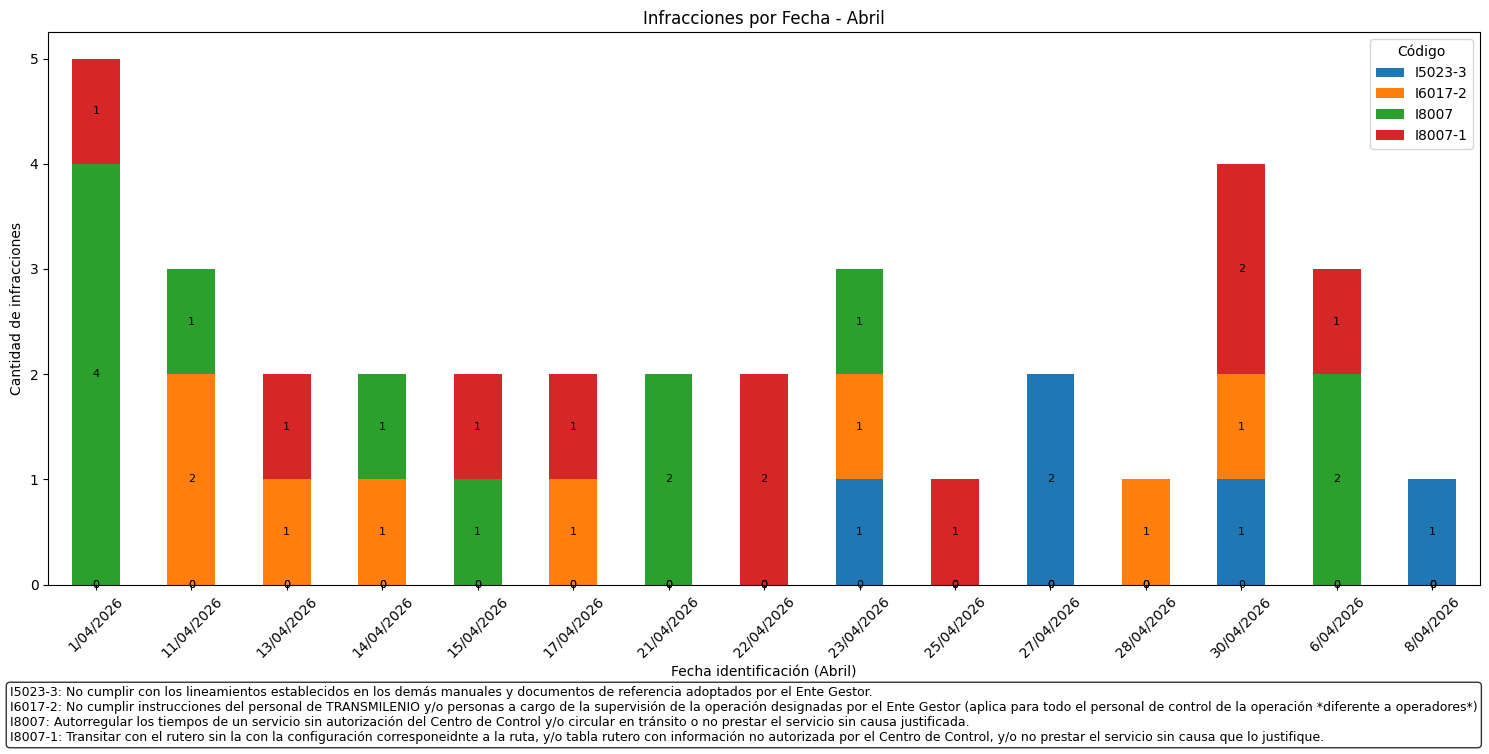

In [49]:
# 🔹 Asegurar formato fecha
ico_procesado['Fecha  identificación '] = (
    ico_procesado['Fecha  identificación ']
)

# 🔹 Filtrar abril
abril = ico_procesado[
    ico_procesado['Mes'].str.lower().str.strip() == 'abril'
]

# 🔹 Agrupar
df_plot = (
    abril
    .groupby(['Fecha  identificación ', 'Cód. Infracción TMSA'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 🔹 Graficar
fig, ax = plt.subplots(figsize=(15,7))
df_plot.plot(kind='bar', stacked=True, ax=ax)

# 🔹 Etiquetas en barras
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8)

# 🔹 Títulos
ax.set_xlabel('Fecha identificación (Abril)')
ax.set_ylabel('Cantidad de infracciones')
ax.set_title('Infracciones por Fecha - Abril')

# 🔹 Leyenda principal
ax.legend(title='Código', loc='upper right')

# 🔹 Crear mapa código → descripción
mapa_desc = (
    ico_procesado[['Cód. Infracción TMSA', 'Descripción']]
    .drop_duplicates()
    .set_index('Cód. Infracción TMSA')['Descripción']
    .to_dict()
)

# 🔹 Texto de segunda leyenda (solo los que están en la gráfica)
texto_leyenda = "\n".join([
    f"{cod}: {mapa_desc.get(cod, '')}"
    for cod in df_plot.columns
])

# 🔹 Ajustar espacio inferior
plt.subplots_adjust(bottom=0.10)

# 🔹 Cuadro de descripción abajo
fig.text(
    0.01, -0.07,
    texto_leyenda,
    fontsize=9,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

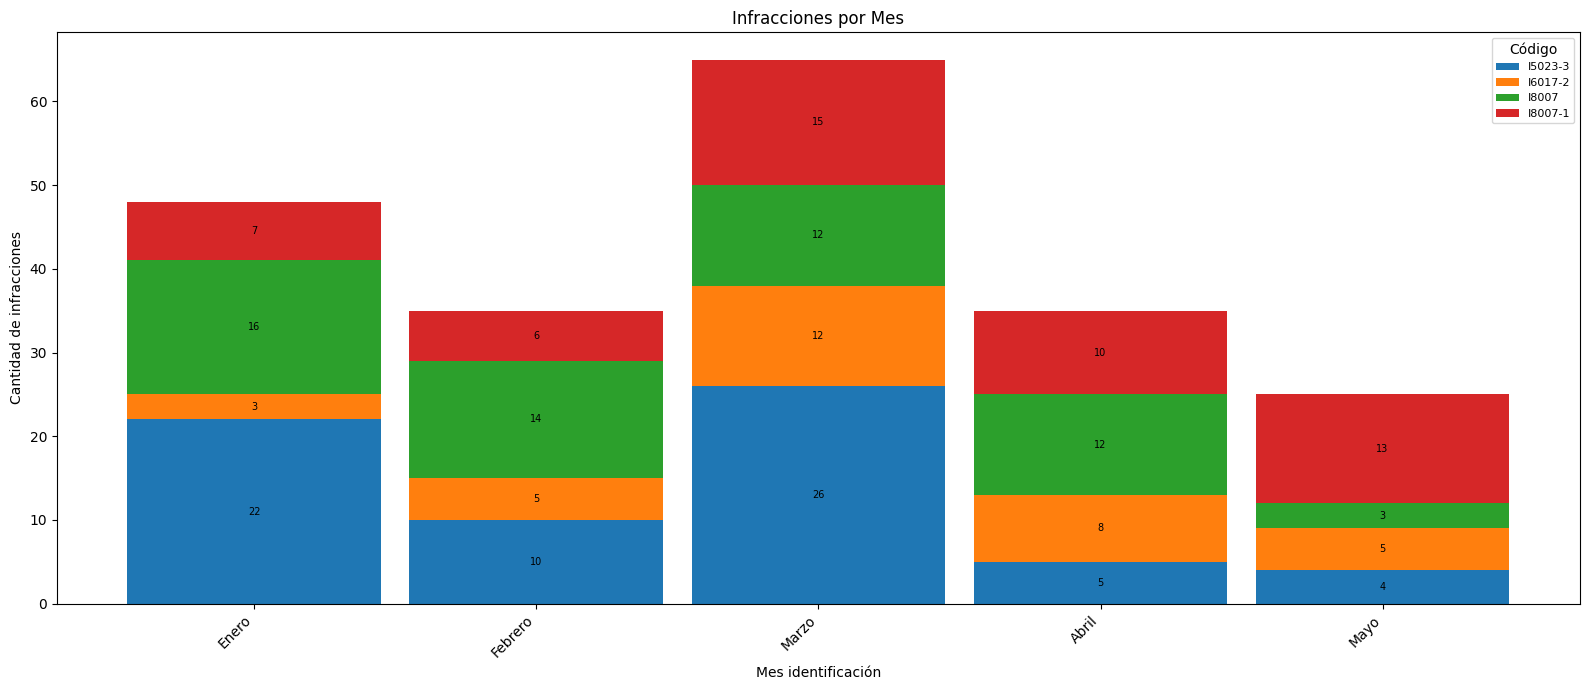

In [50]:
# 🔹 Fecha
ico_procesado['Fecha  identificación '] = pd.to_datetime(
    ico_procesado['Fecha  identificación '],
    dayfirst=True,
    errors='coerce'
)

# 🔹 Mes numérico
ico_procesado['Mes_num'] = ico_procesado['Fecha  identificación '].dt.month

# 🔹 Mes en español
meses_es = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
ico_procesado['Mes_nom'] = ico_procesado['Mes_num'].map(meses_es)

# 🔹 Agrupar
df_plot = (
    ico_procesado
    .groupby(['Mes_num', 'Mes_nom', 'Cód. Infracción TMSA'])
    .size()
    .unstack(fill_value=0)
    .sort_index(level=0)
)

# 🔹 Usar solo nombre
df_plot.index = df_plot.index.get_level_values('Mes_nom')

# 🔹 Graficar
fig, ax = plt.subplots(figsize=(16,7))

df_plot.plot(kind='bar', stacked=True, ax=ax, width=0.9)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

ax.set_xlabel('Mes identificación')
ax.set_ylabel('Cantidad de infracciones')
ax.set_title('Infracciones por Mes')

ax.legend(title='Código', loc='upper right', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

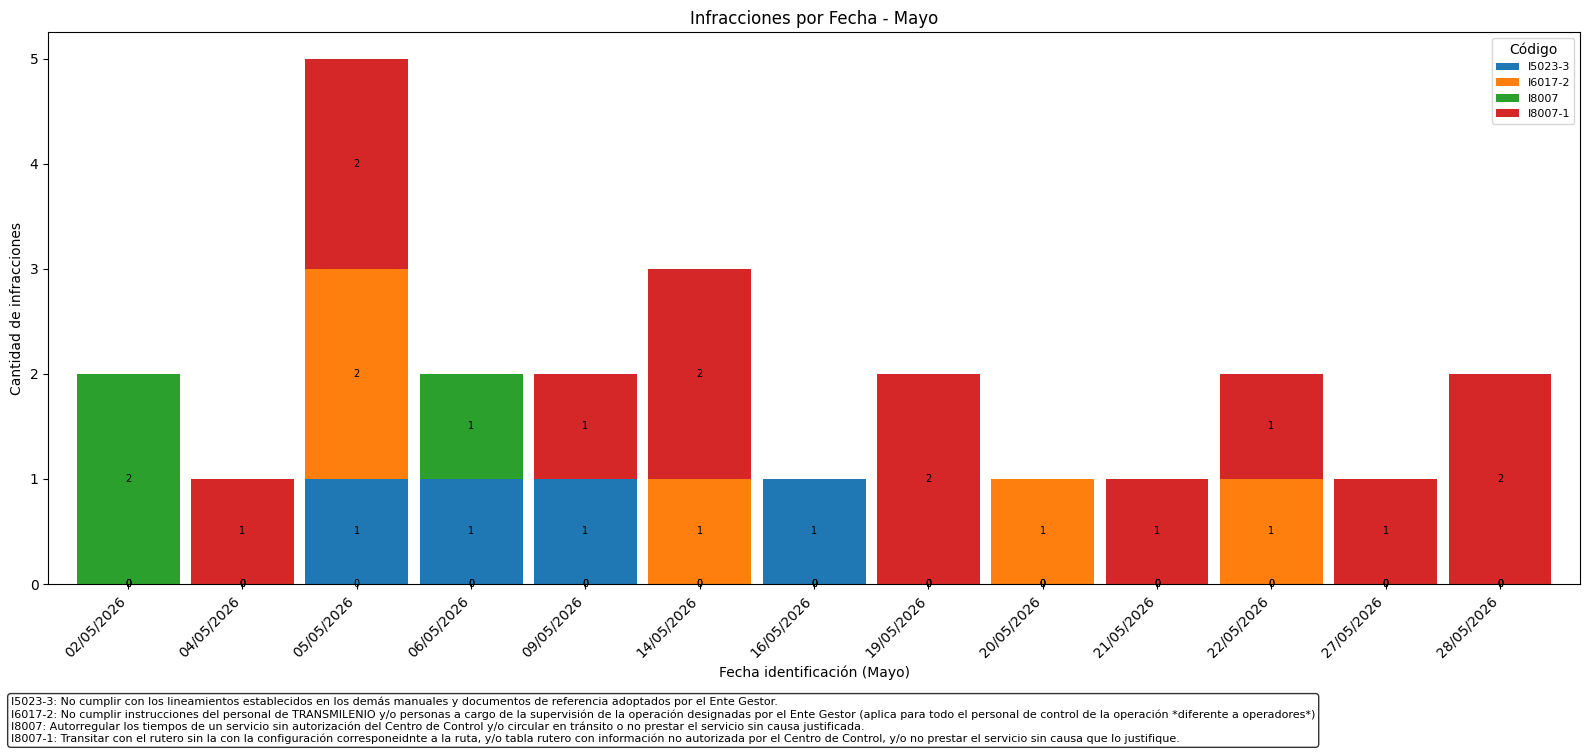

In [51]:
# 🔹 1. Asegurar formato fecha (CLAVE)
ico_procesado['Fecha  identificación '] = pd.to_datetime(
    ico_procesado['Fecha  identificación '],
    dayfirst=True,
    errors='coerce'
)

# 🔹 2. Filtrar abril
abril = ico_procesado[
    ico_procesado['Mes'].str.lower().str.strip() == 'mayo'
]

# 🔹 3. Agrupar y ordenar por fecha
df_plot = (
    abril
    .groupby(['Fecha  identificación ', 'Cód. Infracción TMSA'])
    .size()
    .unstack(fill_value=0)
    .sort_index()   # 🔥 ahora sí ordena correctamente
)

# 🔹 4. Convertir índice a texto SOLO para mostrar
df_plot.index = df_plot.index.strftime('%d/%m/%Y')

# 🔹 5. Graficar
fig, ax = plt.subplots(figsize=(16,7))

df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.9
)

# 🔹 6. Etiquetas en barras
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

# 🔹 7. Títulos
ax.set_xlabel('Fecha identificación (Mayo)')
ax.set_ylabel('Cantidad de infracciones')
ax.set_title('Infracciones por Fecha - Mayo')

# 🔹 8. Leyenda principal
ax.legend(title='Código', loc='upper right', fontsize=8)

# 🔹 9. Crear mapa código → descripción
mapa_desc = (
    ico_procesado[['Cód. Infracción TMSA', 'Descripción']]
    .drop_duplicates()
    .set_index('Cód. Infracción TMSA')['Descripción']
    .to_dict()
)

# 🔹 10. Texto de segunda leyenda
texto_leyenda = "\n".join([
    f"{cod}: {mapa_desc.get(cod, '')}"
    for cod in df_plot.columns
])

# 🔹 11. Ajustar espacio (MEJORADO)
plt.subplots_adjust(bottom=0.35)

# 🔹 12. Cuadro de descripción
fig.text(
    0.01, -0.07,
    texto_leyenda,
    fontsize=8,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# 🔹 13. Rotación de fechas
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

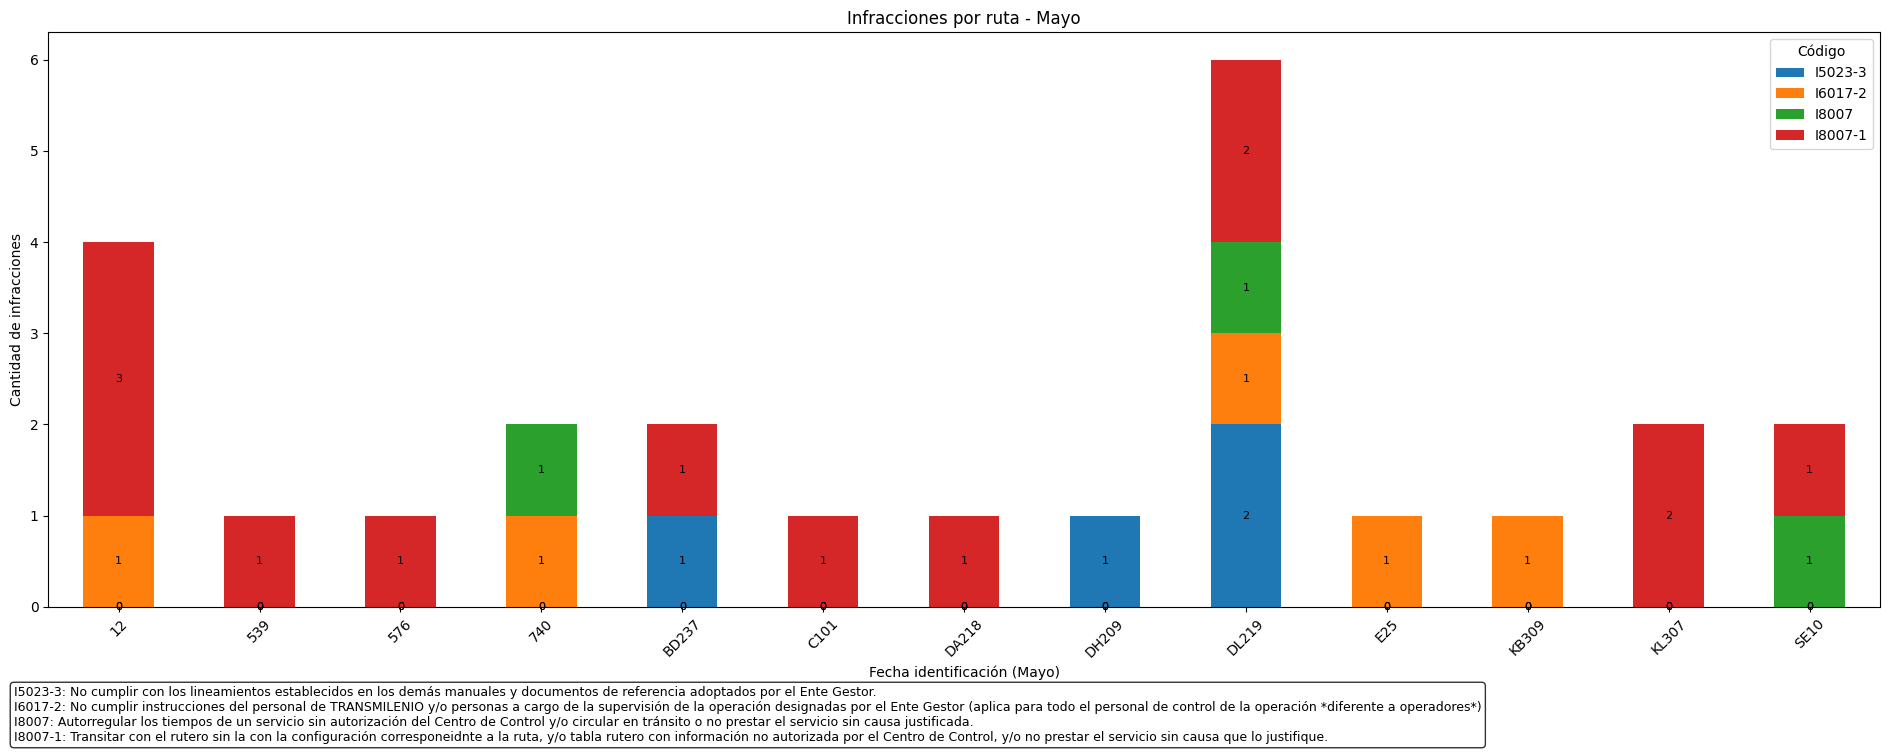

In [52]:
# 🔹 Filtrar rutas
abril = ico_procesado[
    ico_procesado['Mes'].str.lower().str.strip() == 'mayo'
]

# 🔹 Agrupar
df_plot = (
    abril
    .groupby(['Ruta', 'Cód. Infracción TMSA'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 🔹 Graficar
fig, ax = plt.subplots(figsize=(19,7))
df_plot.plot(kind='bar', stacked=True, ax=ax)

# 🔹 Etiquetas en barras
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8)

# 🔹 Títulos
ax.set_xlabel('Fecha identificación (Mayo)')
ax.set_ylabel('Cantidad de infracciones')
ax.set_title('Infracciones por ruta - Mayo')

# 🔹 Leyenda principal
ax.legend(title='Código', loc='upper right')

# 🔹 Crear mapa código → descripción
mapa_desc = (
    ico_procesado[['Cód. Infracción TMSA', 'Descripción']]
    .drop_duplicates()
    .set_index('Cód. Infracción TMSA')['Descripción']
    .to_dict()
)

# 🔹 Texto de segunda leyenda (solo los que están en la gráfica)
texto_leyenda = "\n".join([
    f"{cod}: {mapa_desc.get(cod, '')}"
    for cod in df_plot.columns
])

# 🔹 Ajustar espacio inferior
plt.subplots_adjust(bottom=0.10)

# 🔹 Cuadro de descripción abajo
fig.text(
    0.01, -0.07,
    texto_leyenda,
    fontsize=9,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

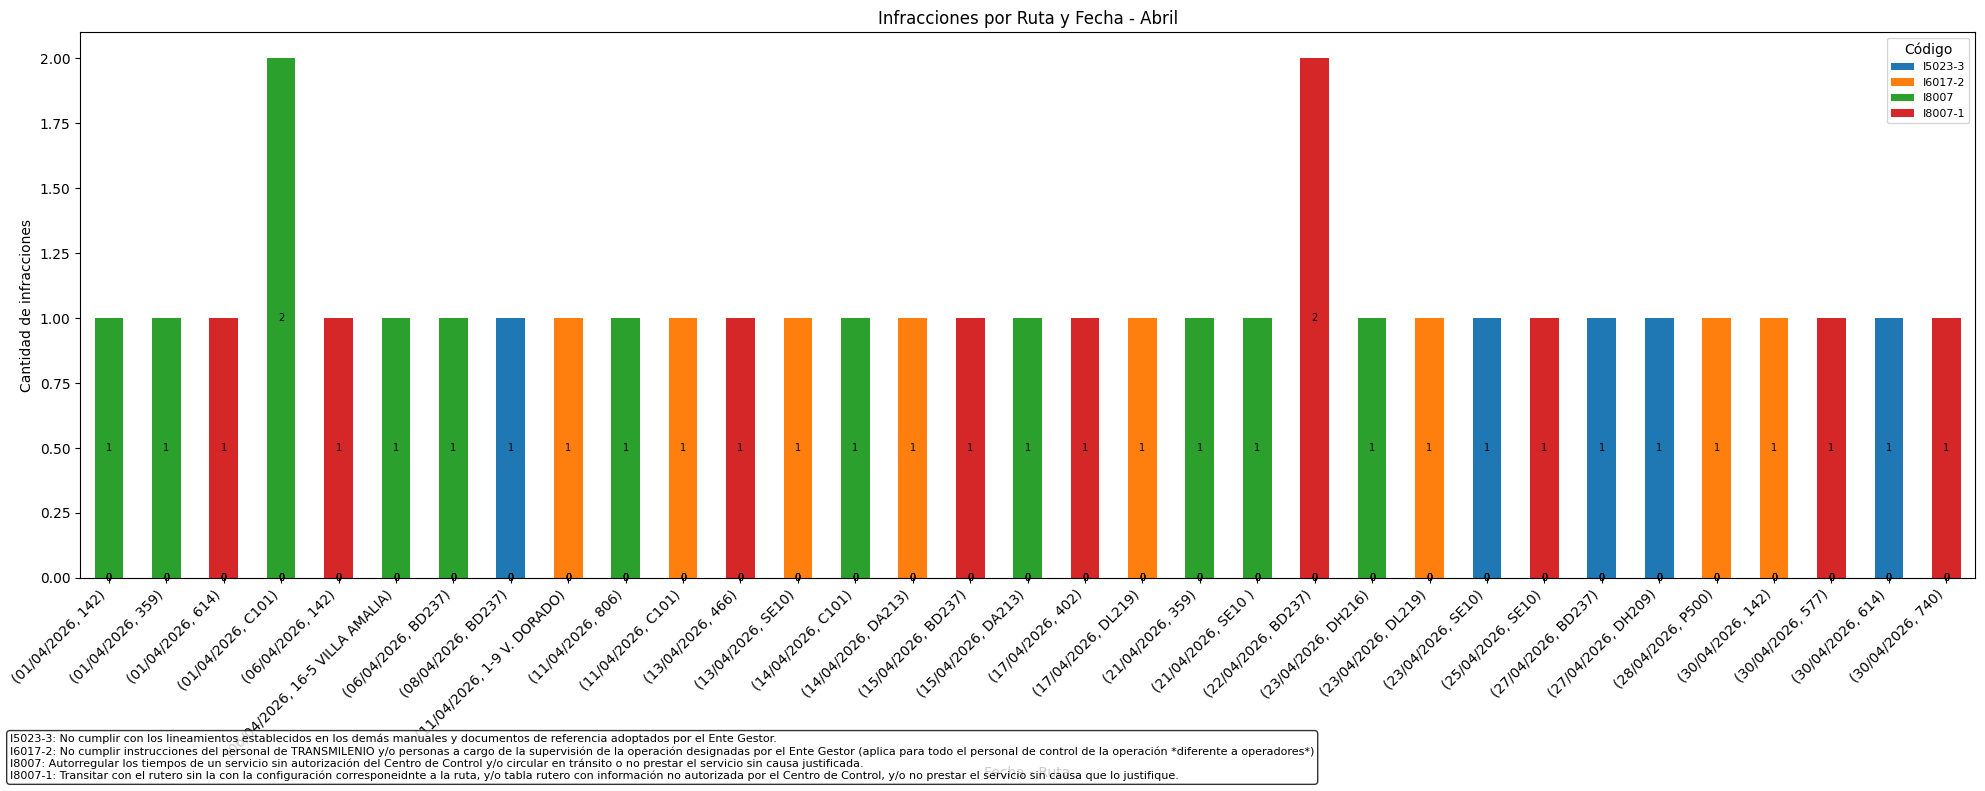

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Asegurar formato fecha
ico_procesado['Fecha  identificación '] = pd.to_datetime(
    ico_procesado['Fecha  identificación '],
    dayfirst=True,
    errors='coerce'
)

# 🔹 Filtrar abril
abril = ico_procesado[
    ico_procesado['Mes'].str.lower().str.strip() == 'abril'
]

# 🔹 Agrupar por Fecha + Ruta + Código
df_plot = (
    abril
    .groupby(['Fecha  identificación ', 'Ruta', 'Cód. Infracción TMSA'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 🔹 Convertir fecha a texto para el eje X
df_plot.index = df_plot.index.set_levels(
    df_plot.index.levels[0].strftime('%d/%m/%Y'),
    level=0
)

# 🔹 Graficar
fig, ax = plt.subplots(figsize=(20,8))

df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

# 🔹 Etiquetas en barras
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=7)

# 🔹 Títulos
ax.set_xlabel('Fecha - Ruta')
ax.set_ylabel('Cantidad de infracciones')
ax.set_title('Infracciones por Ruta y Fecha - Abril')

# 🔹 Leyenda principal
ax.legend(title='Código', loc='upper right', fontsize=8)

# 🔹 Crear mapa código → descripción
mapa_desc = (
    ico_procesado[['Cód. Infracción TMSA', 'Descripción']]
    .drop_duplicates()
    .set_index('Cód. Infracción TMSA')['Descripción']
    .to_dict()
)

# 🔹 Segunda leyenda
texto_leyenda = "\n".join([
    f"{cod}: {mapa_desc.get(cod, '')}"
    for cod in df_plot.columns
])

# 🔹 Ajuste de espacio
plt.subplots_adjust(bottom=0.35)

fig.text(
    0.01, 0.02,
    texto_leyenda,
    fontsize=8,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ruteros

In [54]:
ico_ruteros = ico_procesado.copy()

In [55]:
valores = ['I8007-1']

ico_ruteros = ico_ruteros[ico_ruteros['Cód. Infracción TMSA'].isin(valores)]

ico_ruteros.head(2)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,Área,Patio,Año,Mes,item_rutero,flag_rutero,item_novedad,flag_indumentaria,Mes_num,Mes_nom
11,71661761832,1698700,40057,Int. Operaciones,2026-01-03,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,Operaciones,TINTAL,2026,enero,RUTERO / SEÑALIZACIÓN,0,nan,0,1,Enero
43,71661761860,1701513,40850,Int. Operaciones,2026-01-07,9/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,508959,...,Operaciones,TINTAL,2026,enero,RUTERO / SEÑALIZACIÓN,0,nan,0,1,Enero


In [56]:
col = ico_ruteros['DESCRIPCIÓN DE NOVEDAD'].astype(str)

# 🔹 1. HORA (todo lo que tenga :)
ico_ruteros['hora_novedad'] = col.str.extract(r'(\d{1,2}:\d{2})')[0]

# 🔹 Extraer los que NO tienen ':' (tipo 0652)
sin_dos_puntos = col.str.extract(r'\b(\d{4})\b')[0]

# 🔹 Convertir a formato HH:MM
sin_dos_puntos = sin_dos_puntos.str[:2] + ':' + sin_dos_puntos.str[2:]

# 🔹 Completar los valores faltantes
ico_ruteros['hora_novedad'] = ico_ruteros['hora_novedad'].fillna(sin_dos_puntos)

# 🔹 2. RUTA
ico_ruteros['ruta_novedad'] = col.str.extract(
    r'(DL\d+|BD\d+|KL\d+|KB\d+|DH\d+|DA\d+|DD\d+|GC\d+|SE\d+|C\d+|RT\s*\d+|'
    r'\b(?:577|614|740|576|466|402|P500|E25|DB237|539|128)\b|'
    r'SERVICIO\s*[^/]+|RUTA\s*[A-Z0-9]+)',
    flags=re.IGNORECASE
)[0]

# limpiar "Ruta"
ico_ruteros['ruta_novedad'] = (
    ico_ruteros['ruta_novedad']
    .str.replace(r'RUTA\s*', '', regex=True)
    .str.strip()
)

# 🔹 3. TABLA
ico_ruteros['tabla_novedad'] = (
    col.str.extract(r'((?:TABLA|TB|TBL)\s*\d+)', flags=re.IGNORECASE)[0]
    .fillna('0')
)

# 🔹 4. DIRECCIÓN
ico_ruteros['direccion_novedad'] = col.str.extract(
    r'([^/]*(AV\.?|AVENIDA|CALLE|CRA\.?|CARRERA|BOYACÁ|BOYACA|CALI|Portal|Transversal|CARACAS)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

#Bus

ico_ruteros['bus_novedad'] = (
    col.str.upper()
    
    # 🔹 limpiar ruido
    .str.replace(r'MÓVIL|MOVIL|ZONAL|ZZ', '', regex=True)
    
    # 🔹 extraer bus completo (con números obligatorios)
    .str.extract(r'(Z?\s*(?:50|52)\s*-?\s*\d{3,5})', flags=re.IGNORECASE)[0]
    
    # 🔹 limpiar espacios
    .str.replace(r'\s+', '', regex=True)
    
    # 🔹 estandarizar formato
    .str.replace(r'^(50|52)', r'Z\1', regex=True)
    .str.replace(r'Z(50|52)(\d+)', r'Z\1-\2', regex=True)
    
    # 🔹 llenar vacíos
    .fillna('0')
)

#NOVEDAD (texto operativo)
ico_ruteros['novedad_val'] = col.str.extract(
    r'([^/]*(SE EVIDENCIA|SE EVIDENCIÓ|NO ACTIVA|OPERADOR OMITE|El OPERADOR|TRANSITA|EVIDENCIADO|INVADE|TRANSITANDO|OMITIR|LUZ|DIRECCIONAL|CARRIL|SE PRESENTA NOVEDAD|RETORNO|TRANSITA|RUTERO|ELECTRONICO|SIN TABLA|APAGADO|'
    r'NOVEDAD|ELEMENTO|MALETA|LUCES?|MARCHA|IRREGULAR|USUARIO|PARE|SEMAFORO|ACTIVA|DESVIO|NO AUTORIZADO|AUDIFONOS|AURICULAR|PUERTA|DESVÍO|DESVÍA|SIN AUTORIZACION|PARADA|ALTERAR|MANIPULACION|DISPOSITIVO|'
    r'PRENDAS|VELOCIDAD|EXCESO)[^/]*)',
    flags=re.IGNORECASE
)[0].str.strip()

ico_ruteros.head(2)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,item_novedad,flag_indumentaria,Mes_num,Mes_nom,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
11,71661761832,1698700,40057,Int. Operaciones,2026-01-03,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,nan,0,1,Enero,07:48,Ruta 806,Tabla 3,Dirección Avenida Boyacá con Calle 12C,Z50-4178,Operador es evidenciado con los rutero electró...
43,71661761860,1701513,40850,Int. Operaciones,2026-01-07,9/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,508959,...,nan,0,1,Enero,16:44,Ruta 806,Tabla 16,Dirección Avenida Boyacá Con Calle 12B,Z50-4265,Operador es evidenciado transitando sin tabla ...


In [57]:
ico_ruteros['direccion_novedad'] = (
    ico_ruteros['direccion_novedad']
    .astype(str)
    .str.replace(r'(?i)\bdirecci[oó]n\b\s*', '', regex=True)
)

ico_ruteros.head(2)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,item_novedad,flag_indumentaria,Mes_num,Mes_nom,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val
11,71661761832,1698700,40057,Int. Operaciones,2026-01-03,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,nan,0,1,Enero,07:48,Ruta 806,Tabla 3,Avenida Boyacá con Calle 12C,Z50-4178,Operador es evidenciado con los rutero electró...
43,71661761860,1701513,40850,Int. Operaciones,2026-01-07,9/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,508959,...,nan,0,1,Enero,16:44,Ruta 806,Tabla 16,Avenida Boyacá Con Calle 12B,Z50-4265,Operador es evidenciado transitando sin tabla ...


In [58]:
ico_ruteros['hora_nov'] = ico_ruteros['hora_novedad']

ico_ruteros.head(2)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,flag_indumentaria,Mes_num,Mes_nom,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,hora_nov
11,71661761832,1698700,40057,Int. Operaciones,2026-01-03,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,0,1,Enero,07:48,Ruta 806,Tabla 3,Avenida Boyacá con Calle 12C,Z50-4178,Operador es evidenciado con los rutero electró...,07:48
43,71661761860,1701513,40850,Int. Operaciones,2026-01-07,9/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,508959,...,0,1,Enero,16:44,Ruta 806,Tabla 16,Avenida Boyacá Con Calle 12B,Z50-4265,Operador es evidenciado transitando sin tabla ...,16:44


In [59]:
def fix_time(time_str):
    try:
        time_str = str(time_str).strip()
        parts = list(map(int, time_str.split(':')))

        # 🔹 Completar si viene sin segundos
        if len(parts) == 2:
            h, m = parts
            s = 0
        elif len(parts) == 3:
            h, m, s = parts
        else:
            return None

        # 🔹 Convertir a segundos
        total_segundos = h * 3600 + m * 60 + s

        # 🔹 Ajustar a 24h
        total_segundos = total_segundos % (24 * 3600)

        # 🔹 Volver a formato HH:MM:SS
        h_new = total_segundos // 3600
        m_new = (total_segundos % 3600) // 60
        s_new = total_segundos % 60

        return f"{h_new:02}:{m_new:02}:{s_new:02}"

    except:
        return None

ico_ruteros['hora_nov']  = ico_ruteros['hora_nov'] .astype(str)

ico_ruteros['hora_nov']  = ico_ruteros['hora_nov'] .apply(fix_time)

ico_ruteros['hora_nov']  = pd.to_datetime(
    ico_ruteros['hora_nov'] ,
    format='%H:%M:%S',
    errors='coerce'
)

ico_ruteros['Hora_Segundos'] = (
    ico_ruteros['hora_nov'] .dt.hour * 3600 +
    ico_ruteros['hora_nov'] .dt.minute * 60 +
    ico_ruteros['hora_nov'] .dt.second
)

ico_ruteros.head(2)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,Mes_num,Mes_nom,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,hora_nov,Hora_Segundos
11,71661761832,1698700,40057,Int. Operaciones,2026-01-03,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,1,Enero,07:48,Ruta 806,Tabla 3,Avenida Boyacá con Calle 12C,Z50-4178,Operador es evidenciado con los rutero electró...,1900-01-01 07:48:00,28080
43,71661761860,1701513,40850,Int. Operaciones,2026-01-07,9/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,508959,...,1,Enero,16:44,Ruta 806,Tabla 16,Avenida Boyacá Con Calle 12B,Z50-4265,Operador es evidenciado transitando sin tabla ...,1900-01-01 16:44:00,60240


In [60]:
ico_ruteros['Fecha_ico'] = ico_ruteros['Fecha  identificación ']

ico_ruteros.head(2)

,ID GMOVIL,ID Novedad TMSA,Consecutivo interventoría,Componente,Fecha identificación,Fecha de notificación,Cód. Infracción TMSA,Descripción,puntos,Cod. Operador,...,Mes_nom,hora_novedad,ruta_novedad,tabla_novedad,direccion_novedad,bus_novedad,novedad_val,hora_nov,Hora_Segundos,Fecha_ico
11,71661761832,1698700,40057,Int. Operaciones,2026-01-03,6/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,506697,...,Enero,07:48,Ruta 806,Tabla 3,Avenida Boyacá con Calle 12C,Z50-4178,Operador es evidenciado con los rutero electró...,1900-01-01 07:48:00,28080,2026-01-03
43,71661761860,1701513,40850,Int. Operaciones,2026-01-07,9/01/2026,I8007-1,Transitar con el rutero sin la con la configur...,30,508959,...,Enero,16:44,Ruta 806,Tabla 16,Avenida Boyacá Con Calle 12B,Z50-4265,Operador es evidenciado transitando sin tabla ...,1900-01-01 16:44:00,60240,2026-01-07


In [61]:
in_con.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/tabla_ico_inop.csv', index=False, sep=';')

In [62]:
ico_procesado.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/tabla_ico_control.csv', index=False, sep=';')

In [63]:
ico_ruteros.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/tabla_ico_ruteros.csv', index=False, sep=';')

In [64]:
varados.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/tabla_ico_varados.csv', index=False, sep=';')

In [65]:
ruteros.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/tabla_ico_varados_rut.csv', index=False, sep=';')

In [66]:
in_consol.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/tabla_ico_fms.csv', index=False, sep=';')